In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

print("⏳ [1/2] กำลังโหลดข้อมูลและแปลงรูปภาพเป็น Array...")
df = pd.read_csv("./Dataset/utkface_labels.csv")
IMG_SIZE = 64 

X_images, y_age, y_gender = [], [], []
for index, row in tqdm(df.iterrows(), total=len(df)):
    img_path = row['relative_path']
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        X_images.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
        y_age.append(row['age'])
        y_gender.append(row['gender'])

X_images = np.array(X_images)
y_age = np.array(y_age)
y_gender = np.array(y_gender)

# Flatten และทำ Normalization
X_flat = X_images.reshape(X_images.shape[0], -1) / 255.0

print("\n⏳ [2/2] กำลังรัน PCA เพื่อลดมิติข้อมูล...")
pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_flat)
print(f"✨ PCA เสร็จสิ้น! Total Explained Variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

⏳ [1/2] กำลังโหลดข้อมูลและแปลงรูปภาพเป็น Array...


100%|██████████| 22856/22856 [08:09<00:00, 46.66it/s] 



⏳ [2/2] กำลังรัน PCA เพื่อลดมิติข้อมูล...
✨ PCA เสร็จสิ้น! Total Explained Variance: 93.00%


📊 ผลลัพธ์ LAB 1: Regression Performance
🔹 Simple Linear Regression   -> MAE: 14.99 ปี | R²: 0.0201
🔹 Multiple Linear Regression -> MAE: 12.86 ปี | R²: 0.2778
🔹 Random Forest Regressor   -> MAE: 11.95 ปี | R²: 0.3446


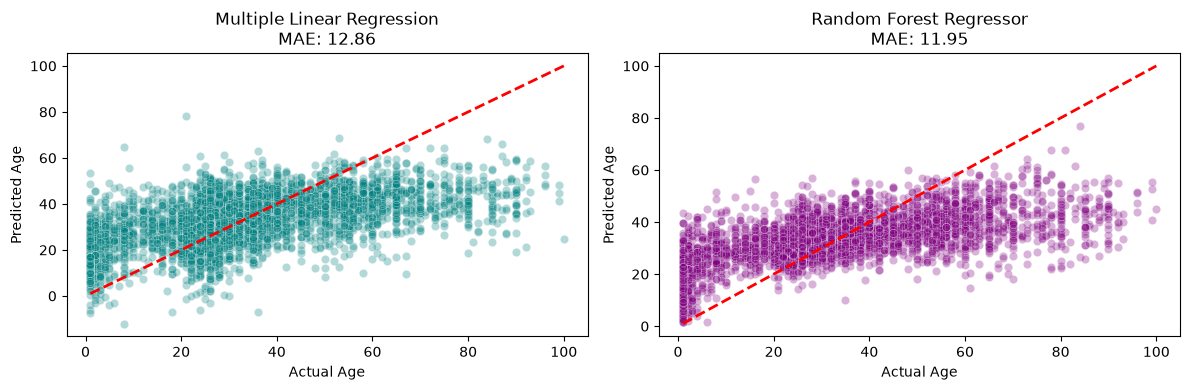

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. แบ่งข้อมูลสำหรับ Regression (Train 80%, Test 20%)
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_pca, y_age, test_size=0.2, random_state=42)

# 2. Simple Linear Regression (ใช้เฉพาะ PCA Component ที่ 1 ฟีเจอร์เดียว)
X_train_simple = X_train_age[:, 0].reshape(-1, 1)
X_test_simple = X_test_age[:, 0].reshape(-1, 1)
simple_reg = LinearRegression().fit(X_train_simple, y_train_age)
y_pred_simple = simple_reg.predict(X_test_simple)

# 3. Multiple Linear Regression (ใช้ครบ 100 ฟีเจอร์)
multi_reg = LinearRegression().fit(X_train_age, y_train_age)
y_pred_multi = multi_reg.predict(X_test_age)

# 4. Random Forest Regressor (ใช้ครบ 100 ฟีเจอร์)
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1).fit(X_train_age, y_train_age)
y_pred_rf = rf_reg.predict(X_test_age)

# 5. แสดงผลเปรียบเทียบประสิทธิภาพ
print("==================================================")
print("📊 ผลลัพธ์ LAB 1: Regression Performance")
print("==================================================")
print(f"🔹 Simple Linear Regression   -> MAE: {mean_absolute_error(y_test_age, y_pred_simple):.2f} ปี | R²: {r2_score(y_test_age, y_pred_simple):.4f}")
print(f"🔹 Multiple Linear Regression -> MAE: {mean_absolute_error(y_test_age, y_pred_multi):.2f} ปี | R²: {r2_score(y_test_age, y_pred_multi):.4f}")
print(f"🔹 Random Forest Regressor   -> MAE: {mean_absolute_error(y_test_age, y_pred_rf):.2f} ปี | R²: {r2_score(y_test_age, y_pred_rf):.4f}")

# 6. พลอตกราฟเปรียบเทียบการทำนายอายุ
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_age, y=y_pred_multi, alpha=0.3, color='teal')
plt.plot([y_test_age.min(), y_test_age.max()], [y_test_age.min(), y_test_age.max()], 'r--', lw=2)
plt.title(f"Multiple Linear Regression\nMAE: {mean_absolute_error(y_test_age, y_pred_multi):.2f}")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_age, y=y_pred_rf, alpha=0.3, color='purple')
plt.plot([y_test_age.min(), y_test_age.max()], [y_test_age.min(), y_test_age.max()], 'r--', lw=2)
plt.title(f"Random Forest Regressor\nMAE: {mean_absolute_error(y_test_age, y_pred_rf):.2f}")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.tight_layout()
plt.show()

📊 ผลลัพธ์ LAB 2: Classification Metrics
🔹 Accuracy  : 0.7710
🔹 Precision : 0.7820
🔹 Recall    : 0.7346
🔹 F1-Score  : 0.7576


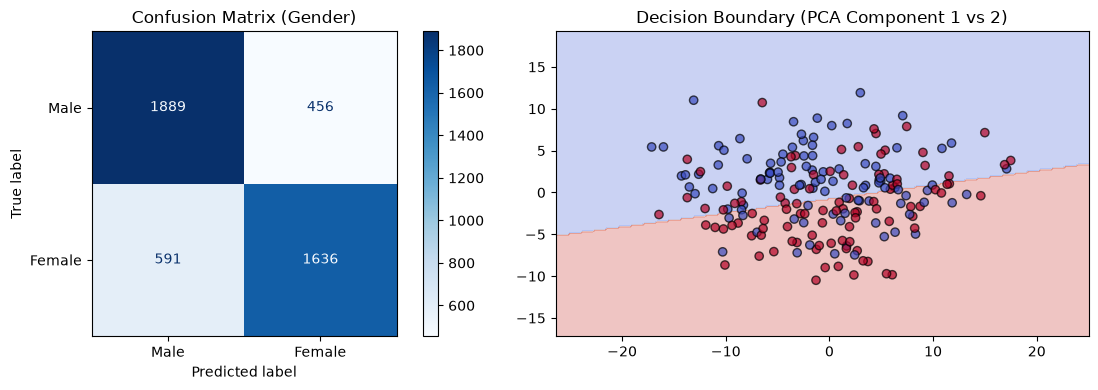

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. แบ่งข้อมูลสำหรับ Classification (Train 80%, Test 20%)
X_train_gen, X_test_gen, y_train_gen, y_test_gen = train_test_split(X_pca, y_gender, test_size=0.2, random_state=42)

# 2. เทรนโมเดล Logistic Regression
clf_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_gen, y_train_gen)
y_pred_gen = clf_model.predict(X_test_gen)

print("==================================================")
print("📊 ผลลัพธ์ LAB 2: Classification Metrics")
print("==================================================")
print(f"🔹 Accuracy  : {accuracy_score(y_test_gen, y_pred_gen):.4f}")
print(f"🔹 Precision : {precision_score(y_test_gen, y_pred_gen):.4f}")
print(f"🔹 Recall    : {recall_score(y_test_gen, y_pred_gen):.4f}")
print(f"🔹 F1-Score  : {f1_score(y_test_gen, y_pred_gen):.4f}")

# 3. วาดกราฟ Confusion Matrix และ Decision Boundary
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_gen, y_pred_gen)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Male", "Female"])
disp.plot(ax=plt.gca(), cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Gender)")

plt.subplot(1, 2, 2)
clf_2d = LogisticRegression().fit(X_train_gen[:, :2], y_train_gen)
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
idx = np.random.choice(len(X_test_gen), 200, replace=False) # สุ่ม 200 จุดมาแสดงผล
plt.scatter(X_test_gen[idx, 0], X_test_gen[idx, 1], c=y_test_gen[idx], alpha=0.7, cmap="coolwarm", edgecolors="k")
plt.title("Decision Boundary (PCA Component 1 vs 2)")
plt.tight_layout()
plt.show()

📊 ผลลัพธ์ LAB 3: Model Comparison & Overfitting Check
🔹 Gender Training Accuracy : 77.84%
🔹 Gender Testing Accuracy  : 77.10%
🔹 Performance Gap          : 0.74%


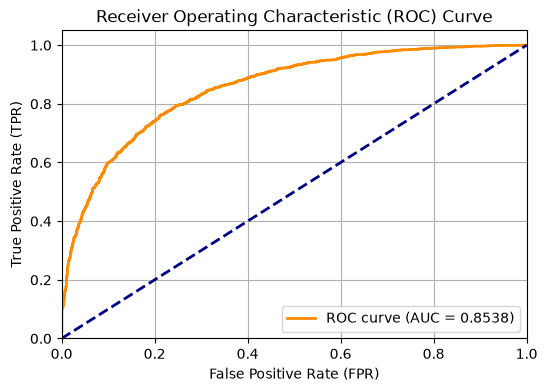

In [14]:
from sklearn.metrics import roc_curve, auc

# 1. เช็คประสิทธิภาพการแยกเพศระหว่างชุดข้อมูล Train vs Test
train_acc = clf_model.score(X_train_gen, y_train_gen)
test_acc = clf_model.score(X_test_gen, y_test_gen)

print("==================================================")
print("📊 ผลลัพธ์ LAB 3: Model Comparison & Overfitting Check")
print("==================================================")
print(f"🔹 Gender Training Accuracy : {train_acc * 100:.2f}%")
print(f"🔹 Gender Testing Accuracy  : {test_acc * 100:.2f}%")
print(f"🔹 Performance Gap          : {abs(train_acc - test_acc) * 100:.2f}%")

# 2. พลอตกราฟ ROC Curve แสดงขีดความสามารถการจำแนกประเภท (Classification Performance)
y_prob_gen = clf_model.predict_proba(X_test_gen)[:, 1]
fpr, tpr, _ = roc_curve(y_test_gen, y_prob_gen)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()